In [45]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

graph_dir = Path("../graphs")
graph_dir.mkdir(exist_ok=True)
plot_counter = 1

def save_plot():
    global plot_counter
    path = graph_dir / f"data{plot_counter}.png"
    plt.savefig(path, bbox_inches="tight")
    plot_counter += 1
    return path


df = pd.read_csv(Path("../data/loans.csv"))
print("shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head(10).to_string(index=False))
print("\nData types:")
print(df.dtypes.to_string())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:")
print(df.duplicated().sum())

shape: (1000, 5)

Columns:
['income', 'credit_score', 'loan_amount', 'employment_years', 'loan_status']

First few rows:
 income  credit_score  loan_amount  employment_years  loan_status
 141958           760        43525                16            1
  35795           846        37556                 4            1
  20860           552        17595                11            1
 123694           689         6969                10            1
 148106           555        48753                14            0
 139879           749        22275                 2            1
 130268           309         9470                 0            0
  96820           541        15225                19            1
  74886           550        47324                15            0
  26265           304        46974                 1            0

Data types:
income              int64
credit_score        int64
loan_amount         int64
employment_years    int64
loan_status         int64

Missing v

### 1. Dataset overview
This cell loads the loan dataset, checks the schema, prints the first rows, and confirms the data quality before analysis.


 ----------Loan status analysis---------------

Loan status count:
loan_status
1    500
0    500
Name: count, dtype: int64

Loan status percentage:
loan_status
1    50.0
0    50.0
Name: proportion, dtype: float64


Saved plot: ..\graphs\data1.png


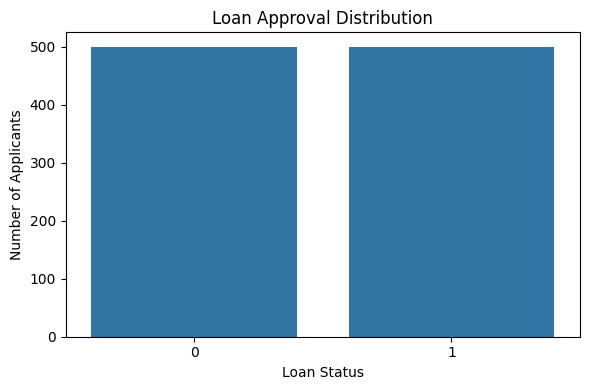

In [46]:
print("\n ----------Loan status analysis---------------")
print("\nLoan status count:")
print(df["loan_status"].value_counts())
print("\nLoan status percentage:")
print(
    df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="loan_status")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

### 2. Loan status distribution
This cell counts approved and rejected applications and visualizes the target variable to see how balanced the dataset is.


 ---------------income analysis--------------- 
count      1000.000000
mean      85838.794000
std       37817.509802
min       20206.000000
25%       53567.250000
50%       86399.500000
75%      117864.000000
max      149981.000000
Name: income, dtype: float64
Saved plot: ..\graphs\data2.png


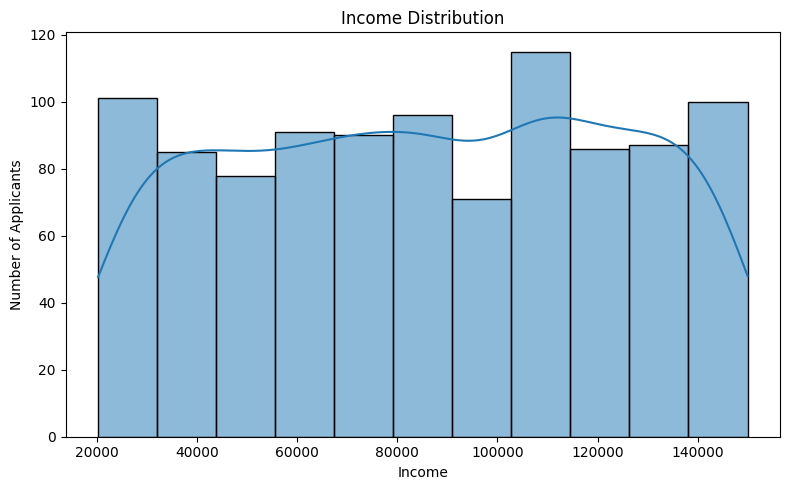


 -----------loan amount analysis------------------------
count     1000.000000
mean     27871.183000
std      12766.885606
min       5097.000000
25%      16508.000000
50%      28632.000000
75%      38473.500000
max      49976.000000
Name: loan_amount, dtype: float64
Saved plot: ..\graphs\data3.png


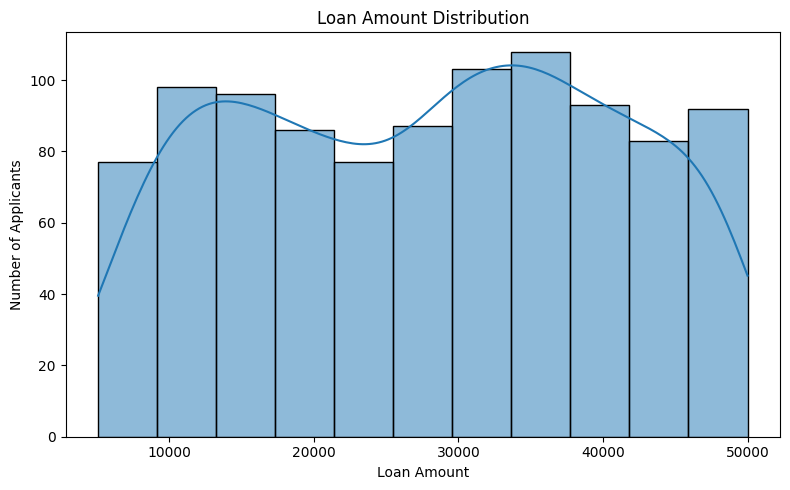


 ---------------credit score analysis--------------------
count    1000.00000
mean      565.29700
std       160.80247
min       300.00000
25%       424.50000
50%       567.00000
75%       698.50000
max       849.00000
Name: credit_score, dtype: float64
Saved plot: ..\graphs\data4.png


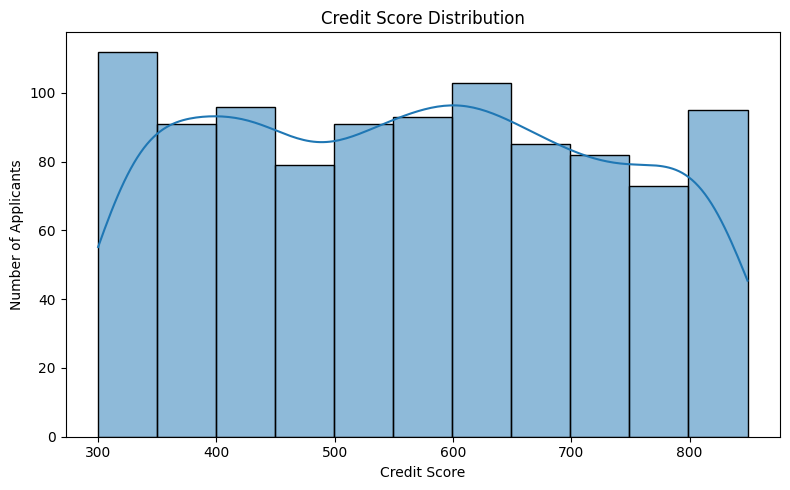


-------------- employment years analysis -------------
count    1000.000000
mean        9.493000
std         5.740462
min         0.000000
25%         4.000000
50%        10.000000
75%        14.000000
max        19.000000
Name: employment_years, dtype: float64

Employment Years Frequency:
employment_years
0     44
1     49
2     55
3     58
4     48
5     50
6     39
7     56
8     61
9     36
10    49
11    49
12    63
13    44
14    56
15    36
16    66
17    41
18    54
19    46
Name: count, dtype: int64
Saved plot: ..\graphs\data5.png


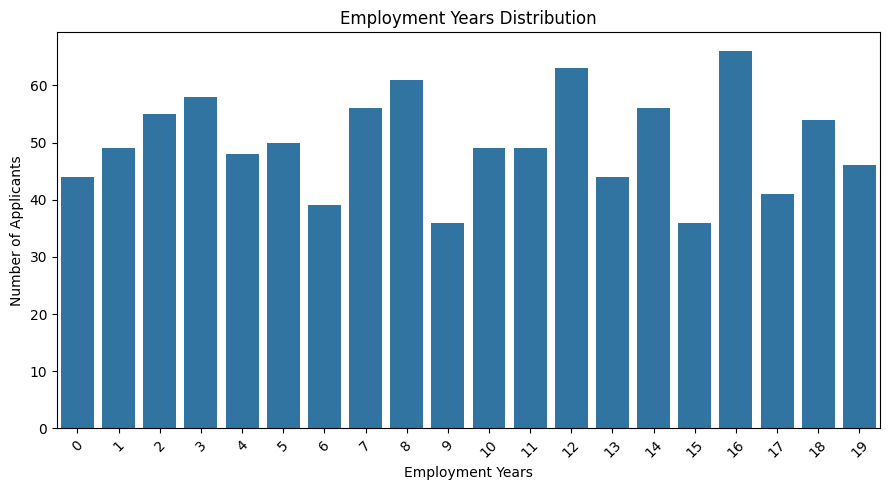

In [47]:
print("\n ---------------income analysis--------------- ")
print(df["income"].describe())
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="income", kde=True)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Applicants")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

print("\n -----------loan amount analysis------------------------")
print(df["loan_amount"].describe())
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="loan_amount", kde=True)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

print("\n ---------------credit score analysis--------------------")
print(df["credit_score"].describe())
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="credit_score", kde=True)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

print("\n-------------- employment years analysis -------------")
print(df["employment_years"].describe())
print("\nEmployment Years Frequency:")
print(df["employment_years"].value_counts().sort_index())
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="employment_years")
plt.title("Employment Years Distribution")
plt.xlabel("Employment Years")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=45)
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

### 3. Income and loan distribution
This cell explores income, loan amount, credit score, and employment duration to understand the feature distribution and identify skewness.


------------- credit score analysis ----------------
Credit score frequency:
credit_score
617    8
338    7
383    6
528    6
825    6
      ..
666    1
484    1
726    1
593    1
683    1
Name: count, Length: 443, dtype: int64

Credit score vs loan status:
loan_status   0  1
credit_score      
300           4  0
301           2  0
302           3  0
303           2  0
304           3  0
...          .. ..
845           0  3
846           0  2
847           0  3
848           0  1
849           0  4

[443 rows x 2 columns]

Loan approval percentage by credit score:
loan_status       0      1
credit_score              
300           100.0    0.0
301           100.0    0.0
302           100.0    0.0
303           100.0    0.0
304           100.0    0.0
...             ...    ...
845             0.0  100.0
846             0.0  100.0
847             0.0  100.0
848             0.0  100.0
849             0.0  100.0

[443 rows x 2 columns]
Saved plot: ..\graphs\data6.png


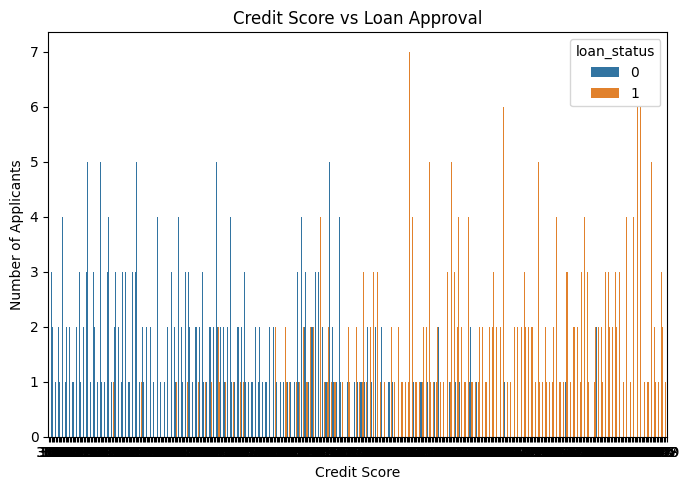


 --------------------employment years vs loan status--------------------
loan_status        0   1
employment_years        
0                 30  14
1                 36  13
2                 29  26
3                 37  21
4                 24  24
5                 31  19
6                 26  13
7                 37  19
8                 34  27
9                 19  17
10                25  24
11                20  29
12                24  39
13                23  21
14                26  30
15                12  24
16                21  45
17                18  23
18                17  37
19                11  35

Loan approval percentage by employment years:
loan_status           0      1
employment_years              
0                 68.18  31.82
1                 73.47  26.53
2                 52.73  47.27
3                 63.79  36.21
4                 50.00  50.00
5                 62.00  38.00
6                 66.67  33.33
7                 66.07  33.93
8                 5

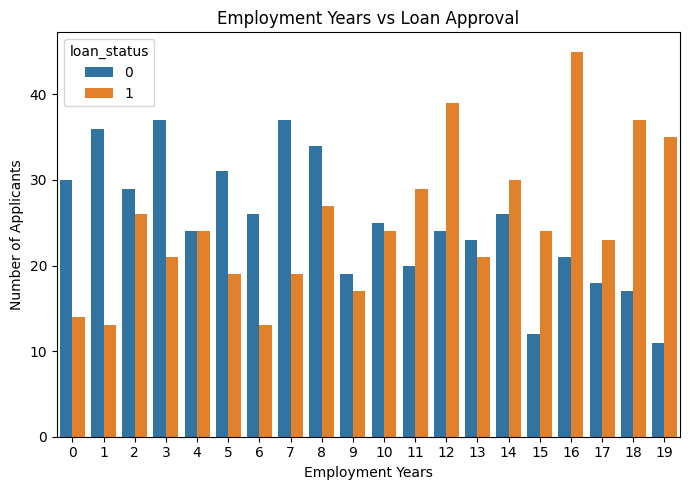

In [48]:
print("\n------------- credit score analysis ----------------")
print("Credit score summary:")
print(df["credit_score"].describe())
print("\nCredit score vs loan status:")
print(pd.crosstab(df["credit_score"], df["loan_status"], dropna=False))
print("\nLoan approval percentage by credit score:")
print(
    pd.crosstab(df["credit_score"], df["loan_status"], normalize="index", dropna=False)
    .mul(100)
    .round(2)
)
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="credit_score",
    hue="loan_status",
    bins=15,
    element="step",
    common_norm=False,
)
plt.title("Credit Score Distribution by Loan Status")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

print("\n --------------------employment years vs loan status--------------------")
print(pd.crosstab(df["employment_years"], df["loan_status"]))
print("\nLoan approval percentage by employment years:")
print(
    pd.crosstab(df["employment_years"], df["loan_status"], normalize="index")
    .mul(100)
    .round(2)
)
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="employment_years", hue="loan_status")
plt.title("Employment Years vs Loan Approval")
plt.xlabel("Employment Years")
plt.ylabel("Number of Applicants")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

### 4. Credit score and employment comparisons
This cell compares credit score and employment years against loan approval and reveals how these variables relate to the target.


----------- loan amount vs loan status-----------------
loan_status  0  1
loan_amount      
5097         0  1
5145         1  0
5161         0  1
5162         0  1
5163         0  1
...         .. ..
49857        1  0
49912        0  1
49918        1  0
49936        1  0
49976        1  0

[984 rows x 2 columns]

Loan approval percentage by loan amount:
loan_status      0      1
loan_amount              
5097           0.0  100.0
5145         100.0    0.0
5161           0.0  100.0
5162           0.0  100.0
5163           0.0  100.0
...            ...    ...
49857        100.0    0.0
49912          0.0  100.0
49918        100.0    0.0
49936        100.0    0.0
49976        100.0    0.0

[984 rows x 2 columns]
Saved plot: ..\graphs\data8.png


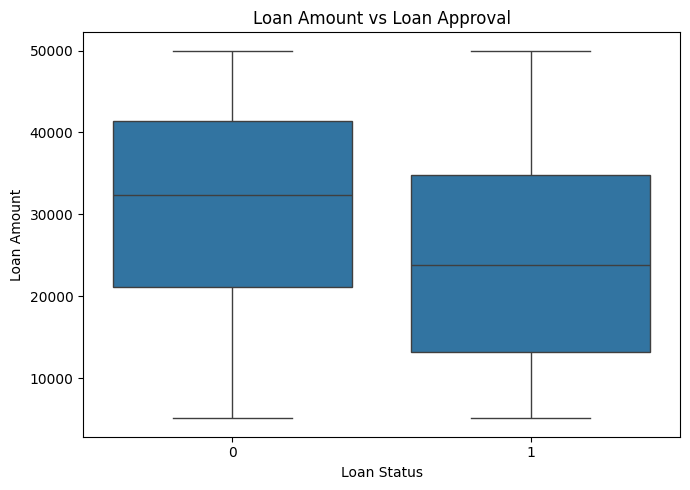


------------income vs loan status--------------
             count       mean           std      min       25%      50%  \
loan_status                                                               
0            500.0  82509.568  38347.030768  20206.0  49475.00  80484.5   
1            500.0  89168.020  37020.095508  20412.0  58426.25  90910.0   

                   75%       max  
loan_status                       
0            114321.75  149695.0  
1            120715.00  149981.0  
Saved plot: ..\graphs\data9.png


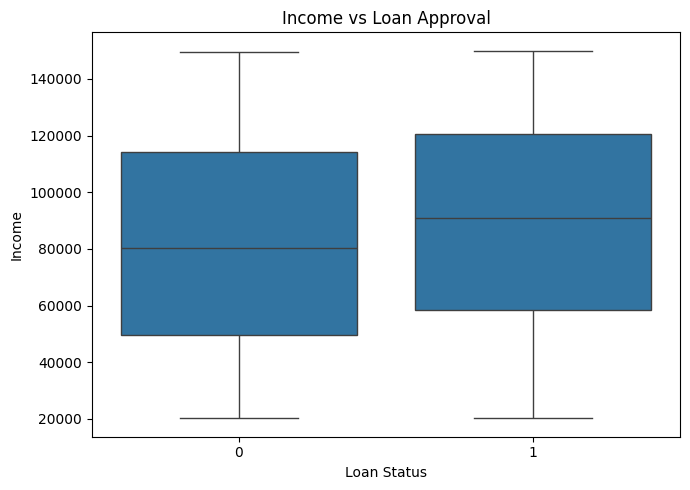

In [49]:
print("\n----------- loan amount vs loan status-----------------")
print(pd.crosstab(df["loan_amount"], df["loan_status"]))
print("\nLoan approval percentage by loan amount:")
print(
    pd.crosstab(df["loan_amount"], df["loan_status"], normalize="index")
    .mul(100)
    .round(2)
)
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="loan_status", y="loan_amount")
plt.title("Loan Amount vs Loan Approval")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

print("\n------------income vs loan status--------------")
print(df.groupby("loan_status")["income"].describe())
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="loan_status", y="income")
plt.title("Income vs Loan Approval")
plt.xlabel("Loan Status")
plt.ylabel("Income")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

### 6. Credit score and employment trends
This cell summarizes loan approval patterns by credit score and employment years and shows whether these variables strongly separate approved and rejected applications.


----------------credit score summary------------------
             count     mean         std    min     25%    50%    75%    max
loan_status                                                                
0            500.0  442.862  102.337426  300.0  357.25  427.0  518.0  800.0
1            500.0  687.732  106.080150  350.0  616.75  694.0  776.0  849.0
Saved plot: ..\graphs\data12.png


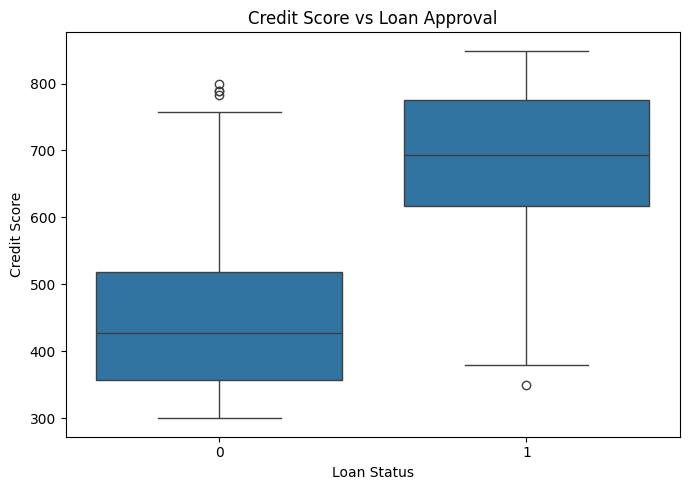


========== EMPLOYMENT YEARS VS LOAN STATUS ==========
loan_status        0   1
employment_years        
0                 30  14
1                 36  13
2                 29  26
3                 37  21
4                 24  24
5                 31  19
6                 26  13
7                 37  19
8                 34  27
9                 19  17
10                25  24
11                20  29
12                24  39
13                23  21
14                26  30
15                12  24
16                21  45
17                18  23
18                17  37
19                11  35

Loan approval percentage by employment years:
loan_status           0      1
employment_years              
0                 68.18  31.82
1                 73.47  26.53
2                 52.73  47.27
3                 63.79  36.21
4                 50.00  50.00
5                 62.00  38.00
6                 66.67  33.33
7                 66.07  33.93
8                 55.74  44.26
9      

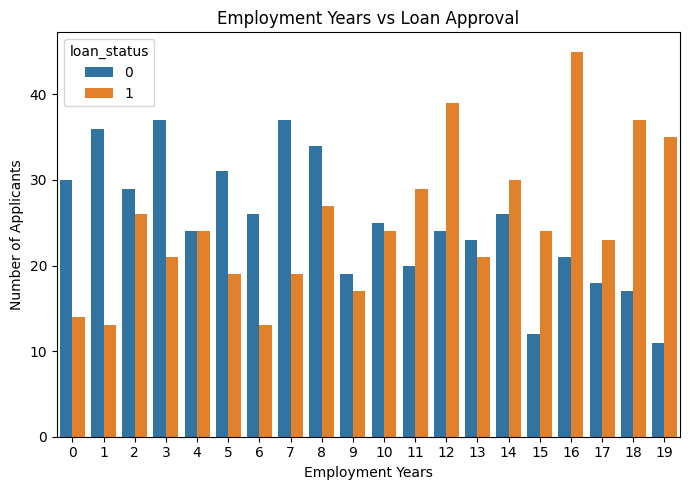

In [51]:
print("\n----------------credit score summary------------------")
print(df.groupby("loan_status")["credit_score"].describe())
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="loan_status", y="credit_score")
plt.title("Credit Score vs Loan Approval")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

print("\n========== EMPLOYMENT YEARS VS LOAN STATUS ==========")
print(pd.crosstab(df["employment_years"], df["loan_status"]))
print("\nLoan approval percentage by employment years:")
print(
    pd.crosstab(df["employment_years"], df["loan_status"], normalize="index")
    .mul(100)
    .round(2)
)
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="employment_years", hue="loan_status")
plt.title("Employment Years vs Loan Approval")
plt.xlabel("Employment Years")
plt.ylabel("Number of Applicants")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

### 7. Outlier and correlation assessment
This cell checks for outliers and reviews how strongly the numerical feature variables correlate with each other before modeling.


========== OUTLIER ANALYSIS ==========

income
Q1: 53567.25
Q3: 117864.0
IQR: 64296.75
Lower Bound: -42877.875
Upper Bound: 214309.125
Number of Outliers: 0

credit_score
Q1: 424.5
Q3: 698.5
IQR: 274.0
Lower Bound: 13.5
Upper Bound: 1109.5
Number of Outliers: 0

loan_amount
Q1: 16508.0
Q3: 38473.5
IQR: 21965.5
Lower Bound: -16440.25
Upper Bound: 71421.75
Number of Outliers: 0

employment_years
Q1: 4.0
Q3: 14.0
IQR: 10.0
Lower Bound: -11.0
Upper Bound: 29.0
Number of Outliers: 0

========== CORRELATION ANALYSIS ==========
                    income  credit_score  loan_amount  employment_years
income            1.000000     -0.032199    -0.001445          0.019916
credit_score     -0.032199      1.000000    -0.017528          0.009148
loan_amount      -0.001445     -0.017528     1.000000          0.020073
employment_years  0.019916      0.009148     0.020073          1.000000
Saved plot: ..\graphs\data14.png


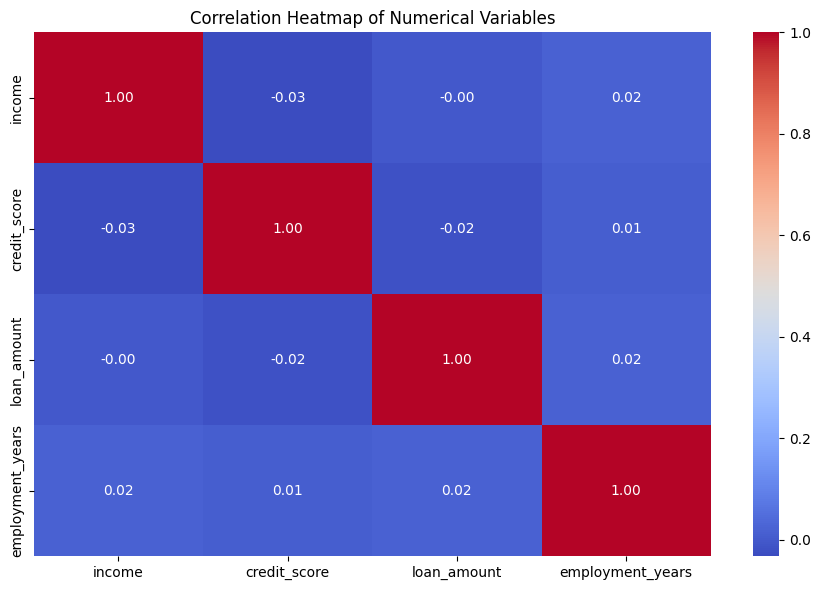


========== FINAL MISSING VALUE SUMMARY ==========
                  Missing Count  Missing Percentage
income                        0                 0.0
credit_score                  0                 0.0
loan_amount                   0                 0.0
employment_years              0                 0.0
loan_status                   0                 0.0


In [52]:
print("\n========== OUTLIER ANALYSIS ==========")

numerical_columns = ["income", "credit_score", "loan_amount", "employment_years"]

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"\n{column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

print("\n========== CORRELATION ANALYSIS ==========")

numeric_columns = ["income", "credit_score", "loan_amount", "employment_years"]
correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix)
plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
file_path = save_plot()
print(f"Saved plot: {file_path}")
plt.show()

print("\n========== FINAL MISSING VALUE SUMMARY ==========")
missing = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage,
})
print(missing_summary)

### 8. Final data quality summary
This final cell summarizes missing values and confirms the dataset is clean enough for modeling and training.